# ArcFace Migros Product Recognition - Training Notebook

**Dataset**: migros_dataset_v1
**Architecture**: Same as arcface_grocery_fixed_v2 (ResNet-34 + ArcFace + HAL)

**Key Adaptations:**
1. Uses migros_dataset_v1 annotation format (CSV with numeric class IDs)
2. Product ID to name mapping via SDP_Product&ID_Dataset_fix.csv
3. Hierarchical category structure (Icecek, Makarna, Pirinc, Sut, Krema_Ve_Sos)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import zipfile

# === UPDATE THIS PATH ===
DRIVE_ZIP_PATH = '/content/drive/MyDrive/datasets/migros_dataset_v6.zip'
EXTRACT_PATH = '/content/migros_dataset'

os.makedirs(EXTRACT_PATH, exist_ok=True)
print(f"Extracting...")
with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print("Done!")

for item in os.listdir(EXTRACT_PATH):
    print(f"  {item}")

Extracting...
Done!
  migros_dataset_v6


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import math
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [7]:
class Config:
    DATASET_ROOT = '/content/migros_dataset/migros_dataset_v6'
    TRAINING_DIR = os.path.join(DATASET_ROOT, 'Training')
    TESTING_DIR = os.path.join(DATASET_ROOT, 'Testing')
    ANNOTATIONS_DIR = os.path.join(DATASET_ROOT, 'Annotations')
    CHECKPOINT_DIR = '/content/drive/MyDrive/migros_checkpoints_v4'

    # Model (same as arcface_grocery)
    FEATURE_DIM = 512
    ARCFACE_SCALE = 64
    ARCFACE_MARGIN = 0.5

    # HAL
    HAL_WEIGHT = 3.0

    # Training
    NUM_EPOCHS = 100
    BATCH_SIZE = 64
    LEARNING_RATE = 0.01
    MIN_LR = 0.0001
    WEIGHT_DECAY = 0.0001

    # Data
    IMAGE_SIZE = 224
    NUM_WORKERS = 4
    SAMPLES_PER_IMAGE = 4  # Each image gets this many augmented samples per epoch

    SAVE_EVERY = 5
    EVAL_EVERY = 5
    SEED = 24

config = Config()
os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
torch.manual_seed(config.SEED)
np.random.seed(config.SEED)
torch.backends.cudnn.benchmark = True

## Step 1: Load Product ID Mapping and Annotations

In [8]:
def load_product_id_mapping(annotations_dir):
    """Load product ID to name mapping from SDP_Product&ID_Dataset_fix.csv"""
    mapping_file = os.path.join(annotations_dir, 'SDP_Product&ID_Dataset_fix.csv')
    id_to_name = {}

    with open(mapping_file, 'r', encoding='utf-8-sig') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',', 1)
            if len(parts) == 2:
                try:
                    product_id = int(parts[0])
                    product_name = parts[1].strip()
                    id_to_name[product_id] = product_name
                except ValueError:
                    continue

    print(f"Loaded {len(id_to_name)} product ID mappings")
    return id_to_name

id_to_name = load_product_id_mapping(config.ANNOTATIONS_DIR)
print(f"\nSample mappings:")
for i, (k, v) in enumerate(list(id_to_name.items())[:5]):
    print(f"  {k}: {v}")

Loaded 115 product ID mappings

Sample mappings:
  1: Lipton Ice Tea Şeftali
  2: Lipton Ice Tea Mango
  3: Lipton Ice Tea Şekersiz Şeftali Aromalı Soğuk Çay Kutu 6 x 330 Ml
  4: Coca-Cola Orijinal Tat Kutu Ml
  5: Sprite Limon Aromalı Kutu Ml


In [9]:
def parse_annotations(annotations_dir, testing_dir, id_to_name):
    """Parse _annotations.csv for test samples."""
    ann_file = os.path.join(annotations_dir, '_annotations.csv')
    all_samples = []
    referenced_product_ids = set()

    df = pd.read_csv(ann_file)
    print(f"Annotations columns: {df.columns.tolist()}")
    print(f"Total annotation rows: {len(df)}")

    for _, row in df.iterrows():
        filename = row['filename']
        product_id = int(row['class'])
        xmin, ymin = int(row['xmin']), int(row['ymin'])
        xmax, ymax = int(row['xmax']), int(row['ymax'])

        image_path = os.path.join(testing_dir, filename)

        if os.path.exists(image_path) and product_id in id_to_name:
            if xmax > xmin and ymax > ymin:
                all_samples.append({
                    'image_path': image_path,
                    'product_id': product_id,
                    'product_name': id_to_name[product_id],
                    'bbox': [xmin, ymin, xmax, ymax]
                })
                referenced_product_ids.add(product_id)

    print(f"Parsed {len(all_samples)} test samples")
    print(f"Found {len(referenced_product_ids)} unique product IDs in annotations")

    return all_samples, referenced_product_ids

test_samples_raw, annotation_product_ids = parse_annotations(
    config.ANNOTATIONS_DIR, config.TESTING_DIR, id_to_name
)

Annotations columns: ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']
Total annotation rows: 580
Parsed 580 test samples
Found 115 unique product IDs in annotations


## Step 2: Build Training Set from Product Images

In [10]:
def normalize_product_name(name):
    """Normalize product name for matching."""
    name = os.path.splitext(name)[0]
    name = name.lower().strip()
    return name

def build_training_set(training_dir, id_to_name, valid_product_ids=None):
    """Build training set from hierarchical folder structure."""
    image_paths = []
    class_to_idx = {}
    idx_to_class = {}
    class_to_category = {}
    categories = set()

    # Build name lookup for matching
    name_to_id = {}
    for pid, pname in id_to_name.items():
        norm_name = normalize_product_name(pname)
        name_to_id[norm_name] = pid

    # Find all training images
    all_images = []
    for root, dirs, files in os.walk(training_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, training_dir)
                all_images.append((full_path, rel_path, file))

    print(f"Total images in Training folder: {len(all_images)}")

    matched_count = 0

    for full_path, rel_path, filename in all_images:
        norm_filename = normalize_product_name(filename)

        # Find matching product ID
        product_id = None
        matched_name = None
        for norm_name, pid in name_to_id.items():
            if norm_name == norm_filename or norm_name in norm_filename or norm_filename in norm_name:
                product_id = pid
                matched_name = norm_name
                break

        if product_id is None:
            continue

        if valid_product_ids is not None and product_id not in valid_product_ids:
            continue

        matched_count += 1
        product_name = id_to_name[product_id]

        # Get category from path
        path_parts = rel_path.replace('\\', '/').split('/')
        category = path_parts[0] if len(path_parts) >= 1 else 'Unknown'
        categories.add(category)

        # Use product NAME only as class identifier (not ID)
        class_name = product_name

        if class_name not in class_to_idx:
            idx = len(class_to_idx)
            class_to_idx[class_name] = idx
            idx_to_class[idx] = class_name
            class_to_category[class_name] = category

        image_paths.append((full_path, class_to_idx[class_name], class_name))

    print(f"Matched {matched_count} training images")

    category_to_idx = {cat: idx for idx, cat in enumerate(sorted(categories))}

    return class_to_idx, idx_to_class, class_to_category, category_to_idx, image_paths

print("Building training set...")
class_to_idx, idx_to_class, class_to_category, category_to_idx, image_paths = build_training_set(
    config.TRAINING_DIR, id_to_name, valid_product_ids=annotation_product_ids
)

NUM_CLASSES = len(class_to_idx)
NUM_CATEGORIES = len(category_to_idx)

print(f"\n=== Dataset Summary ===")
print(f"Training classes: {NUM_CLASSES}")
print(f"Categories: {NUM_CATEGORIES} - {list(category_to_idx.keys())}")

Building training set...
Total images in Training folder: 760
Matched 70 training images

=== Dataset Summary ===
Training classes: 67
Categories: 5 - ['Icecek', 'Krema_Ve_Sos', 'Makarna', 'Pirinc', 'Sut']


## Step 3: Create Test Samples with Class Matching

In [11]:
def build_test_samples(raw_samples, class_to_idx, id_to_name):
    """Match test samples to training class indices."""
    matched_samples = []
    unmatched_samples = []

    for sample in raw_samples:
        product_id = sample['product_id']
        product_name = id_to_name.get(product_id, '')

        # Use product NAME only as class identifier (matches build_training_set)
        class_name = product_name

        if class_name in class_to_idx:
            matched_samples.append({
                'image_path': sample['image_path'],
                'bbox': sample['bbox'],
                'class_idx': class_to_idx[class_name],
                'class_name': class_name
            })
        else:
            unmatched_samples.append({
                'image_path': sample['image_path'],
                'product_id': product_id,
                'product_name': product_name,
                'class_name': class_name
            })

    print(f"Matched {len(matched_samples)} test samples")
    if unmatched_samples:
        print(f"WARNING: {len(unmatched_samples)} samples could not be matched!")
        print(f"\nUnmatched products (not in training set):")
        # Group by product_name to avoid repetition
        unmatched_products = {}
        for s in unmatched_samples:
            pname = s['product_name']
            if pname not in unmatched_products:
                unmatched_products[pname] = {'ids': set(), 'count': 0}
            unmatched_products[pname]['ids'].add(s['product_id'])
            unmatched_products[pname]['count'] += 1
        for pname, info in sorted(unmatched_products.items()):
            ids_str = ', '.join(map(str, sorted(info['ids'])))
            print(f"  '{pname}' (IDs: {ids_str}) - {info['count']} samples")

    return matched_samples

test_samples = build_test_samples(test_samples_raw, class_to_idx, id_to_name)
print(f"\nFinal test samples: {len(test_samples)}")

Matched 579 test samples

Unmatched products (not in training set):
  'Uludağ Efsane Portakal Pet Şekersiz 1 L' (IDs: 20) - 1 samples

Final test samples: 579


## Step 4: Dataset Classes

In [12]:
class MigrosTrainDataset(Dataset):
    def __init__(self, image_paths, class_to_category, category_to_idx, transform=None, samples_per_image=100):
        self.image_paths = image_paths
        self.class_to_category = class_to_category
        self.category_to_idx = category_to_idx
        self.transform = transform
        self.samples_per_image = samples_per_image
        self.cache = {}

        print(f"Caching {len(image_paths)} training images...")
        for path, class_idx, _ in tqdm(image_paths):
            try:
                self.cache[path] = Image.open(path).convert('RGB')
            except Exception as e:
                print(f"Failed to load: {path}")
        print(f"Cached {len(self.cache)} images")
        print(f"Epoch size: {len(self)} ({len(image_paths)} images x {samples_per_image} samples/image)")

    def __len__(self):
        return len(self.image_paths) * self.samples_per_image

    def __getitem__(self, idx):
        # Determine which image this sample corresponds to
        image_idx = idx // self.samples_per_image
        img_path, class_idx, class_name = self.image_paths[image_idx]

        if img_path in self.cache:
            image = self.cache[img_path].copy()
        else:
            image = Image.new('RGB', (224, 224), (128, 128, 128))

        if self.transform:
            image = self.transform(image)

        category = self.class_to_category.get(class_name, list(self.category_to_idx.keys())[0])
        cat_idx = self.category_to_idx[category]

        return image, class_idx, cat_idx


class MigrosTestDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        try:
            image = Image.open(sample['image_path']).convert('RGB')
            x1, y1, x2, y2 = sample['bbox']

            w, h = image.size
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            if x2 > x1 and y2 > y1:
                image = image.crop((x1, y1, x2, y2))
        except:
            image = Image.new('RGB', (224, 224), (128, 128, 128))

        if self.transform:
            image = self.transform(image)

        return image, sample['class_idx']

In [13]:
# Custom transforms
import numpy as np
import random

class AutoCropWhiteBackground:
    """Auto-detect product bounds by finding non-white region."""
    def __init__(self, threshold=240, padding=20, max_size=(1400, 700)):
        self.threshold = threshold
        self.padding = padding
        self.max_size = max_size

    def __call__(self, img):
        img_array = np.array(img)
        non_white = ~np.all(img_array > self.threshold, axis=2)

        rows = np.any(non_white, axis=1)
        cols = np.any(non_white, axis=0)

        if not np.any(rows) or not np.any(cols):
            return transforms.CenterCrop(self.max_size)(img)

        y_min, y_max = np.where(rows)[0][[0, -1]]
        x_min, x_max = np.where(cols)[0][[0, -1]]

        h, w = img_array.shape[:2]
        y_min = max(0, y_min - self.padding)
        y_max = min(h, y_max + self.padding)
        x_min = max(0, x_min - self.padding)
        x_max = min(w, x_max + self.padding)

        cropped = img.crop((x_min, y_min, x_max, y_max))

        crop_w, crop_h = cropped.size
        max_h, max_w = self.max_size
        if crop_h > max_h or crop_w > max_w:
            cropped = transforms.CenterCrop(self.max_size)(cropped)

        return cropped


# Training transform - augment to match test domain
train_transform = transforms.Compose([
    # Auto-crop to product
    AutoCropWhiteBackground(threshold=240, padding=20, max_size=(1400, 700)),
    # Downscale to simulate test resolution (~200px crops)
    transforms.Resize((128, 128)),
    transforms.Resize((256, 256)),
    # Augmentations
    transforms.RandomRotation(15),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.ColorJitter(brightness=(0.5, 0.9), contrast=0.15, saturation=0.1, hue=0.02),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Test transform - NO augmentation, just resize and normalize
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Training transform: AutoCrop → Downscale 128→256 → Rotate → Perspective → ColorJitter → Crop")
print("Test transform: Resize only (NO augmentation)")

Training transform: AutoCrop → Downscale 128→256 → Rotate → Perspective → ColorJitter → Crop
Test transform: Resize only (NO augmentation)


In [14]:
# Create datasets
train_dataset = MigrosTrainDataset(
    image_paths,
    class_to_category,
    category_to_idx,
    transform=train_transform,
    samples_per_image=config.SAMPLES_PER_IMAGE
)

test_dataset = MigrosTestDataset(
    test_samples,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Test: {len(test_dataset)} samples, {len(test_loader)} batches")

Caching 70 training images...


  0%|          | 0/70 [00:00<?, ?it/s]

Cached 70 images
Epoch size: 280 (70 images x 4 samples/image)
Train: 280 samples, 4 batches
Test: 579 samples, 10 batches


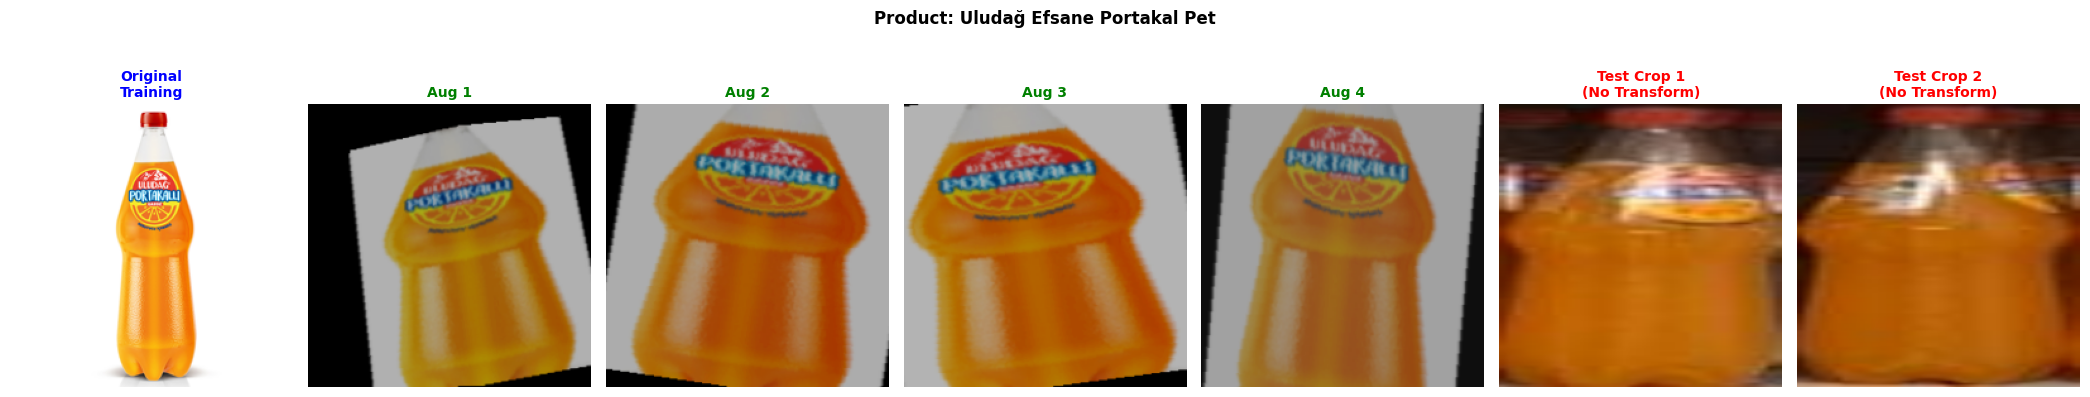

46

In [15]:
# Visualize: 1 product, its augmentations, and test crop
def visualize_product_augmentations(train_dataset, test_dataset, idx_to_class, product_idx=None):
    """
    Show one product: Original → 4 Augmentations → Test Crop(s)
    """

    # Find products that exist in both train and test
    train_classes = {}
    for path, class_idx, class_name in train_dataset.image_paths:
        if class_idx not in train_classes:
            train_classes[class_idx] = path

    test_classes = {}
    for i, sample in enumerate(test_dataset.samples):
        class_idx = sample['class_idx']
        if class_idx not in test_classes:
            test_classes[class_idx] = []
        test_classes[class_idx].append(i)

    common_classes = list(set(train_classes.keys()) & set(test_classes.keys()))

    # Select product
    if product_idx is None:
        product_idx = random.choice(common_classes)

    class_name = idx_to_class[product_idx]
    train_path = train_classes[product_idx]
    test_indices = test_classes[product_idx]

    # Augmentation pipeline for visualization (no ToTensor/Normalize)
    aug_viz = transforms.Compose([
        AutoCropWhiteBackground(threshold=240, padding=20, max_size=(1400, 700)),
        transforms.Resize((128, 128)),
        transforms.Resize((256, 256)),
        transforms.RandomRotation(15),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
        transforms.ColorJitter(brightness=(0.5, 0.9), contrast=0.15, saturation=0.1, hue=0.02),
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    ])

    # No augmentation for test - just resize
    test_viz = transforms.Compose([
        transforms.Resize((224, 224)),
    ])

    # Create figure: Original + 4 augs + test crops
    num_test = min(3, len(test_indices))
    total_cols = 1 + 4 + num_test

    fig, axes = plt.subplots(1, total_cols, figsize=(3*total_cols, 4))

    # Load original training image
    img = Image.open(train_path).convert('RGB')

    # Original
    axes[0].imshow(img.resize((224, 224)))
    axes[0].set_title('Original\nTraining', fontsize=10, fontweight='bold', color='blue')
    axes[0].axis('off')
    for spine in axes[0].spines.values():
        spine.set_visible(True)
        spine.set_color('blue')
        spine.set_linewidth(3)

    # 4 Augmentations
    for i in range(4):
        augmented = aug_viz(img.copy())
        axes[1 + i].imshow(augmented)
        axes[1 + i].set_title(f'Aug {i+1}', fontsize=10, fontweight='bold', color='green')
        axes[1 + i].axis('off')
        for spine in axes[1 + i].spines.values():
            spine.set_visible(True)
            spine.set_color('green')
            spine.set_linewidth(3)

    # Test crops (NO augmentation)
    for i in range(num_test):
        sample = test_dataset.samples[test_indices[i]]
        try:
            test_img = Image.open(sample['image_path']).convert('RGB')
            x1, y1, x2, y2 = sample['bbox']
            w, h = test_img.size
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            if x2 > x1 and y2 > y1:
                test_img = test_img.crop((x1, y1, x2, y2))
            test_img = test_viz(test_img)
        except:
            test_img = Image.new('RGB', (224, 224), (128, 128, 128))

        axes[5 + i].imshow(test_img)
        axes[5 + i].set_title(f'Test Crop {i+1}\n(No Transform)', fontsize=10, fontweight='bold', color='red')
        axes[5 + i].axis('off')
        for spine in axes[5 + i].spines.values():
            spine.set_visible(True)
            spine.set_color('red')
            spine.set_linewidth(3)

    # Product name as title
    plt.suptitle(f'Product: {class_name}', fontsize=12, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    return product_idx

# Run for a random product
visualize_product_augmentations(train_dataset, test_dataset, idx_to_class)

## Step 5: Model Architecture (Same as arcface_grocery)

In [16]:
class ArcFaceHead(nn.Module):
    """ArcFace with margin annealing."""
    def __init__(self, in_features, num_classes, scale=64.0, margin=0.5):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.num_classes = num_classes
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.current_margin = 0.0

    def set_margin(self, margin):
        self.current_margin = min(margin, self.margin)

    def forward(self, embeddings, labels):
        normalized_weights = F.normalize(self.weight, dim=1)
        cosine = F.linear(embeddings, normalized_weights)

        m = self.current_margin
        if m > 0:
            cos_m, sin_m = math.cos(m), math.sin(m)
            th = math.cos(math.pi - m)
            mm = math.sin(math.pi - m) * m

            sine = torch.sqrt(1.0 - cosine.pow(2).clamp(0, 1))
            phi = cosine * cos_m - sine * sin_m
            phi = torch.where(cosine > th, phi, cosine - mm)

            one_hot = F.one_hot(labels, self.num_classes).float()
            output = one_hot * phi + (1 - one_hot) * cosine
        else:
            output = cosine

        return output * self.scale

    def get_proxies(self):
        return F.normalize(self.weight, dim=1)

In [17]:
class HALHead(nn.Module):
    """Hierarchical Auxiliary Loss head."""
    def __init__(self, class_to_category, category_to_idx, scale=64.0):
        super().__init__()
        self.scale = scale
        self.num_categories = len(category_to_idx)
        self.category_to_classes = defaultdict(list)

        for class_name, cat_name in class_to_category.items():
            cat_idx = category_to_idx[cat_name]
            self.category_to_classes[cat_idx].append(class_name)

    def forward(self, embeddings, cat_labels, class_proxies, class_to_idx):
        cat_proxies = []
        for cat_idx in range(self.num_categories):
            class_names = self.category_to_classes[cat_idx]
            class_indices = [class_to_idx[name] for name in class_names if name in class_to_idx]

            if class_indices:
                cat_proxy = class_proxies[class_indices].mean(dim=0)
                cat_proxy = F.normalize(cat_proxy, dim=0)
            else:
                cat_proxy = torch.zeros(class_proxies.size(1), device=class_proxies.device)

            cat_proxies.append(cat_proxy)

        cat_proxies = torch.stack(cat_proxies)
        logits = self.scale * F.linear(embeddings, cat_proxies)
        loss = F.cross_entropy(logits, cat_labels)

        return loss

In [18]:
class ProductRecognitionModel(nn.Module):
    def __init__(self, num_classes, num_categories, class_to_category, category_to_idx,
                 class_to_idx, embedding_dim=512, scale=64.0, margin=0.5):
        super().__init__()

        resnet = models.resnet34(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        self.embedding = nn.Sequential(
            nn.Linear(512, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )

        self.arcface = ArcFaceHead(embedding_dim, num_classes, scale, margin)
        self.hal = HALHead(class_to_category, category_to_idx, scale)
        self.class_to_idx = class_to_idx
        self.embedding_dim = embedding_dim

    def get_embeddings(self, x):
        features = self.backbone(x).flatten(1)
        embeddings = self.embedding(features)
        return F.normalize(embeddings, dim=1)

    def forward(self, x, class_labels=None, cat_labels=None, compute_hal=True):
        embeddings = self.get_embeddings(x)

        if class_labels is not None:
            logits = self.arcface(embeddings, class_labels)
            hal_loss = None
            if compute_hal and cat_labels is not None:
                class_proxies = self.arcface.get_proxies()
                hal_loss = self.hal(embeddings, cat_labels, class_proxies, self.class_to_idx)

            return embeddings, logits, hal_loss

        return embeddings

In [19]:
model = ProductRecognitionModel(
    num_classes=NUM_CLASSES,
    num_categories=NUM_CATEGORIES,
    class_to_category=class_to_category,
    category_to_idx=category_to_idx,
    class_to_idx=class_to_idx,
    embedding_dim=config.FEATURE_DIM,
    scale=config.ARCFACE_SCALE,
    margin=config.ARCFACE_MARGIN
).to(device)

print(f"Model: {NUM_CLASSES} classes, {NUM_CATEGORIES} categories")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 193MB/s]


Model: 67 classes, 5 categories
Parameters: 21,582,656


## Step 6: Training Setup

In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=0.9,
    weight_decay=config.WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.NUM_EPOCHS,
    eta_min=config.MIN_LR
)

scaler = GradScaler()

def get_margin(epoch, warmup=20):
    if epoch < warmup:
        return config.ARCFACE_MARGIN * epoch / warmup
    return config.ARCFACE_MARGIN

In [21]:
def save_checkpoint(model, optimizer, scheduler, epoch, metrics, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'metrics': metrics,
        'num_classes': NUM_CLASSES,
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
        'id_to_name': id_to_name,
    }, path)

def load_checkpoint(model, optimizer, scheduler, path):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    return ckpt['epoch'], ckpt.get('metrics', {})

## Step 7: Training Loop

In [22]:
def train_epoch(model, loader, optimizer, criterion, scaler, device, hal_weight):
    model.train()
    total_loss, total_arc_loss, total_hal_loss = 0, 0, 0
    correct, total = 0, 0

    pbar = tqdm(loader, desc='Training', leave=False)
    for images, class_labels, cat_labels in pbar:
        images = images.to(device, non_blocking=True)
        class_labels = class_labels.to(device, non_blocking=True)
        cat_labels = cat_labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            _, logits, hal_loss = model(images, class_labels, cat_labels, compute_hal=True)
            arc_loss = criterion(logits, class_labels)
            loss = arc_loss
            if hal_loss is not None:
                loss = loss + hal_weight * hal_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_arc_loss += arc_loss.item()
        if hal_loss is not None:
            total_hal_loss += hal_loss.item()

        _, predicted = logits.max(1)
        total += class_labels.size(0)
        correct += predicted.eq(class_labels).sum().item()

        pbar.set_postfix({'loss': f'{loss.item():.3f}', 'acc': f'{100*correct/total:.1f}%'})

    n = len(loader)
    return total_loss/n, total_arc_loss/n, total_hal_loss/n, 100*correct/total

In [23]:
@torch.no_grad()
def build_reference_db(model, image_paths, transform, device):
    model.eval()
    embeddings, labels = [], []

    for path, class_idx, _ in image_paths:
        try:
            image = Image.open(path).convert('RGB')
            image = transform(image).unsqueeze(0).to(device)
            emb = model.get_embeddings(image).cpu().numpy()
            embeddings.append(emb)
            labels.append(class_idx)
        except:
            pass

    return np.vstack(embeddings), np.array(labels)


@torch.no_grad()
def evaluate(model, test_loader, ref_emb, ref_lbl, device, idx_to_class=None, top_confused=10):
    """Evaluate with confusion analysis."""
    model.eval()

    query_emb, query_lbl = [], []
    for images, labels in test_loader:
        emb = model.get_embeddings(images.to(device)).cpu().numpy()
        query_emb.append(emb)
        query_lbl.append(labels.numpy())

    query_emb = np.vstack(query_emb)
    query_lbl = np.concatenate(query_lbl)

    sims = query_emb @ ref_emb.T
    sorted_idx = np.argsort(-sims, axis=1)

    # Standard metrics
    results = {}
    for k in [1, 5, 10, 20]:
        hits = sum(q in ref_lbl[sorted_idx[i, :k]] for i, q in enumerate(query_lbl))
        results[f'HR@{k}'] = 100 * hits / len(query_lbl)

    aps = []
    for i, q in enumerate(query_lbl):
        relevant = ref_lbl[sorted_idx[i]] == q
        if relevant.sum() > 0:
            prec = np.cumsum(relevant) / np.arange(1, len(relevant) + 1)
            aps.append((prec * relevant).sum() / relevant.sum())
    results['mAP'] = 100 * np.mean(aps) if aps else 0

    # Confusion analysis
    confusion_pairs = defaultdict(int)  # (true_class, pred_class) -> count
    class_totals = defaultdict(int)  # true_class -> total queries
    class_correct = defaultdict(int)  # true_class -> correct count

    for i, true_lbl in enumerate(query_lbl):
        pred_lbl = ref_lbl[sorted_idx[i, 0]]  # Top-1 prediction
        class_totals[true_lbl] += 1

        if pred_lbl == true_lbl:
            class_correct[true_lbl] += 1
        else:
            confusion_pairs[(true_lbl, pred_lbl)] += 1

    # Sort confusion pairs by count
    sorted_confusion = sorted(confusion_pairs.items(), key=lambda x: -x[1])

    results['confusion'] = {
        'pairs': sorted_confusion[:top_confused],
        'class_totals': dict(class_totals),
        'class_correct': dict(class_correct)
    }

    return results


def print_confusion_analysis(results, idx_to_class, top_n=10):
    """Print detailed confusion analysis."""
    confusion = results.get('confusion', {})
    pairs = confusion.get('pairs', [])
    class_totals = confusion.get('class_totals', {})
    class_correct = confusion.get('class_correct', {})

    if not pairs:
        return

    print(f"\n  {'='*60}")
    print(f"  TOP {min(top_n, len(pairs))} MOST CONFUSED PAIRS:")
    print(f"  {'='*60}")

    total_errors = sum(count for _, count in pairs)

    for i, ((true_cls, pred_cls), count) in enumerate(pairs[:top_n]):
        true_name = idx_to_class.get(true_cls, f"Class_{true_cls}")
        pred_name = idx_to_class.get(pred_cls, f"Class_{pred_cls}")

        # Truncate long names
        true_name = true_name[:35] + "..." if len(true_name) > 35 else true_name
        pred_name = pred_name[:35] + "..." if len(pred_name) > 35 else pred_name

        pct_of_errors = 100 * count / total_errors if total_errors > 0 else 0
        pct_of_class = 100 * count / class_totals.get(true_cls, 1)

        print(f"  {i+1:2d}. {true_name}")
        print(f"      → {pred_name}")
        print(f"      {count} errors ({pct_of_class:.1f}% of class, {pct_of_errors:.1f}% of all errors)")
        print()

    # Per-class accuracy (worst performing)
    print(f"  {'='*60}")
    print(f"  WORST PERFORMING CLASSES:")
    print(f"  {'='*60}")

    class_acc = {}
    for cls_idx in class_totals:
        total = class_totals[cls_idx]
        correct = class_correct.get(cls_idx, 0)
        class_acc[cls_idx] = (100 * correct / total, correct, total)

    # Sort by accuracy (ascending = worst first)
    sorted_class_acc = sorted(class_acc.items(), key=lambda x: x[1][0])

    for cls_idx, (acc, correct, total) in sorted_class_acc[:10]:
        cls_name = idx_to_class.get(cls_idx, f"Class_{cls_idx}")
        cls_name = cls_name[:40] + "..." if len(cls_name) > 40 else cls_name
        print(f"  {acc:5.1f}% ({correct:2d}/{total:2d}) - {cls_name}")

    print(f"  {'='*60}")

In [24]:
history = {'loss': [], 'arc_loss': [], 'hal_loss': [], 'acc': [], 'lr': [], 'hr1': [], 'hr5': []}

start_epoch = 0
resume_path = os.path.join(config.CHECKPOINT_DIR, 'latest.pth')
if os.path.exists(resume_path):
    start_epoch, _ = load_checkpoint(model, optimizer, scheduler, resume_path)
    print(f"Resumed from epoch {start_epoch}")


In [25]:
print(f"\n{'='*70}")
print(f"Training: {config.NUM_EPOCHS} epochs | {NUM_CLASSES} classes | HAL weight: {config.HAL_WEIGHT}")
print(f"{'='*70}\n")

best_hr1 = 0

for epoch in range(start_epoch, config.NUM_EPOCHS):
    margin = get_margin(epoch)
    model.arcface.set_margin(margin)

    loss, arc_loss, hal_loss, acc = train_epoch(
        model, train_loader, optimizer, criterion, scaler, device, config.HAL_WEIGHT
    )

    lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history['loss'].append(loss)
    history['arc_loss'].append(arc_loss)
    history['hal_loss'].append(hal_loss)
    history['acc'].append(acc)
    history['lr'].append(lr)

    print(f"Epoch {epoch+1:3d}/{config.NUM_EPOCHS} | "
          f"Loss: {loss:.4f} (Arc: {arc_loss:.4f}, HAL: {hal_loss:.4f}) | "
          f"Acc: {acc:.2f}% | LR: {lr:.5f} | M: {margin:.2f}")

    if (epoch + 1) % config.EVAL_EVERY == 0:
        print("  Evaluating...")
        ref_emb, ref_lbl = build_reference_db(model, image_paths, test_transform, device)
        results = evaluate(model, test_loader, ref_emb, ref_lbl, device, idx_to_class)

        hr1, hr5 = results['HR@1'], results['HR@5']
        history['hr1'].append(hr1)
        history['hr5'].append(hr5)

        print(f"  HR@1: {hr1:.2f}% | HR@5: {hr5:.2f}% | HR@10: {results['HR@10']:.2f}% | mAP: {results['mAP']:.2f}%")
        print_confusion_analysis(results, idx_to_class, top_n=10)

        if hr1 > best_hr1:
            best_hr1 = hr1
            save_checkpoint(model, optimizer, scheduler, epoch+1, results,
                          os.path.join(config.CHECKPOINT_DIR, 'best.pth'))
            print(f"  ★ New best!")

    if (epoch + 1) % config.SAVE_EVERY == 0:
        save_checkpoint(model, optimizer, scheduler, epoch+1, {},
                       os.path.join(config.CHECKPOINT_DIR, f'epoch_{epoch+1}.pth'))

    save_checkpoint(model, optimizer, scheduler, epoch+1, {}, resume_path)

print(f"\n{'='*70}")
print(f"Training complete! Best HR@1: {best_hr1:.2f}%")
print(f"{'='*70}")


Training: 100 epochs | 67 classes | HAL weight: 3.0



Training:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch   1/100 | Loss: 17.3865 (Arc: 7.3028, HAL: 3.3613) | Acc: 2.34% | LR: 0.01000 | M: 0.00


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch   2/100 | Loss: 12.9788 (Arc: 7.9756, HAL: 1.6677) | Acc: 3.12% | LR: 0.01000 | M: 0.03


...

Epoch  98/100 | Loss: 0.0003 (Arc: 0.0002, HAL: 0.0000) | Acc: 100.00% | LR: 0.00012 | M: 0.50


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch  99/100 | Loss: 0.0003 (Arc: 0.0001, HAL: 0.0000) | Acc: 100.00% | LR: 0.00011 | M: 0.50


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 100/100 | Loss: 0.0002 (Arc: 0.0001, HAL: 0.0000) | Acc: 100.00% | LR: 0.00010 | M: 0.50
  Evaluating...
  HR@1: 45.08% | HR@5: 73.06% | HR@10: 84.28% | mAP: 57.71%

  TOP 10 MOST CONFUSED PAIRS:
   1. Coca-Cola Orijinal Tat Kutu Ml
      → Coca-Cola Orijinal Tat Pet L
      38 errors (77.6% of class, 27.3% of all errors)

   2. Pepsi Kola Kutu 330 Ml
      → Pepsi Kola L
      19 errors (90.5% of class, 13.7% of all errors)

   3. Coca-Cola Zero Sugar Pet
      → Coca-Cola Orijinal Tat Pet L
      18 errors (90.0% of class, 12.9% of all errors)

   4. Pepsi Zero Sugar Kola Pet
      → Pepsi Kola L
      16 errors (84.2% of class, 11.5% of all errors)

   5. Fanta Portakal Aromalı Kutu Ml
      → Coca-Cola Orijinal Tat Pet L
      10 errors (38.5% of class, 7.2% of all errors)

   6. Torku Süt
      → Pepsi Kola L
      9 errors (45.0% of class, 6.5% of all errors)

   7. Fanta Portakal Aromalı Kutu Ml
      → Pepsi Zero Sugar Kola Pet
      9 errors (34.6% of class, 6.5% of all 

## Step 8: Final Evaluation

In [26]:
# Final evaluation with best model
print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)

best_model_path = os.path.join(config.CHECKPOINT_DIR, 'best_model.pth')
if os.path.exists(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint.get('epoch', '?')}")

print("\nBuilding reference database...")
ref_emb, ref_lbl = build_reference_db(model, image_paths, test_transform, device)

print("Evaluating...")
results = evaluate(model, test_loader, ref_emb, ref_lbl, device, idx_to_class)

print("\n" + "="*50)
print("METRICS")
print("="*50)
for k, v in results.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.2f}%")

# Show confusion analysis
print_confusion_analysis(results, idx_to_class, top_n=15)


FINAL RESULTS

Building reference database...
Evaluating...

METRICS
HR@1: 45.08%
HR@5: 73.06%
HR@10: 84.28%
HR@20: 90.85%
mAP: 57.71%

  TOP 10 MOST CONFUSED PAIRS:
   1. Coca-Cola Orijinal Tat Kutu Ml
      → Coca-Cola Orijinal Tat Pet L
      38 errors (77.6% of class, 27.3% of all errors)

   2. Pepsi Kola Kutu 330 Ml
      → Pepsi Kola L
      19 errors (90.5% of class, 13.7% of all errors)

   3. Coca-Cola Zero Sugar Pet
      → Coca-Cola Orijinal Tat Pet L
      18 errors (90.0% of class, 12.9% of all errors)

   4. Pepsi Zero Sugar Kola Pet
      → Pepsi Kola L
      16 errors (84.2% of class, 11.5% of all errors)

   5. Fanta Portakal Aromalı Kutu Ml
      → Coca-Cola Orijinal Tat Pet L
      10 errors (38.5% of class, 7.2% of all errors)

   6. Torku Süt
      → Pepsi Kola L
      9 errors (45.0% of class, 6.5% of all errors)

   7. Fanta Portakal Aromalı Kutu Ml
      → Pepsi Zero Sugar Kola Pet
      9 errors (34.6% of class, 6.5% of all errors)

   8. Coca-Cola Orijinal T

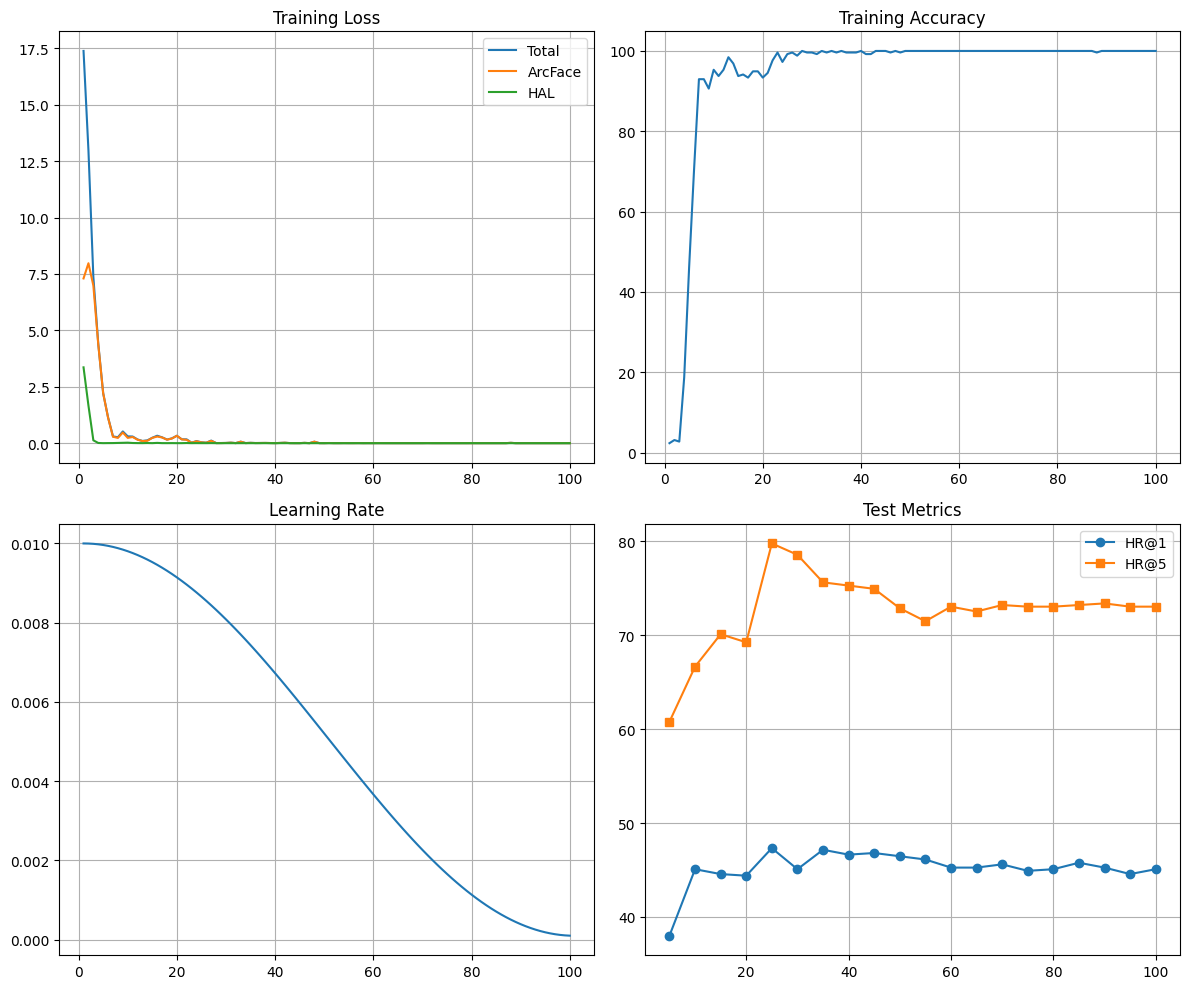

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

epochs = range(1, len(history['loss']) + 1)

axes[0, 0].plot(epochs, history['loss'], label='Total')
axes[0, 0].plot(epochs, history['arc_loss'], label='ArcFace')
axes[0, 0].plot(epochs, history['hal_loss'], label='HAL')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(epochs, history['acc'])
axes[0, 1].set_title('Training Accuracy')
axes[0, 1].grid(True)

axes[1, 0].plot(epochs, history['lr'])
axes[1, 0].set_title('Learning Rate')
axes[1, 0].grid(True)

if history['hr1']:
    eval_epochs = range(config.EVAL_EVERY, len(history['loss'])+1, config.EVAL_EVERY)
    axes[1, 1].plot(eval_epochs, history['hr1'], 'o-', label='HR@1')
    axes[1, 1].plot(eval_epochs, history['hr5'], 's-', label='HR@5')
    axes[1, 1].set_title('Test Metrics')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(config.CHECKPOINT_DIR, 'training_curves.png'), dpi=150)
plt.show()

In [28]:
# Visualization: Query images and Top-5 retrieved results
import random

def visualize_retrieval(model, test_loader, train_dataset, idx_to_class, num_queries=20, top_k=5):
    """Visualize retrieval results for random test queries."""
    model.eval()

    # Get all test embeddings and labels
    test_embeddings = []
    test_labels = []

    print("Extracting test embeddings...")
    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images = images.to(device)
            features = model.get_embeddings(images)
            test_embeddings.append(features.cpu())
            test_labels.extend(labels.tolist())

    test_embeddings = torch.cat(test_embeddings, dim=0)
    test_embeddings = F.normalize(test_embeddings, p=2, dim=1)

    # Get all training embeddings
    print("Extracting training embeddings...")
    train_embeddings = []
    train_labels = []
    train_paths = []

    # Process each unique training image once
    seen_paths = set()
    for path, class_idx, class_name in train_dataset.image_paths:
        if path not in seen_paths:
            seen_paths.add(path)
            train_paths.append(path)
            train_labels.append(class_idx)

    # Batch process training images
    batch_size = 32
    with torch.no_grad():
        for i in tqdm(range(0, len(train_paths), batch_size)):
            batch_paths = train_paths[i:i+batch_size]
            batch_images = []
            for path in batch_paths:
                img = train_dataset.cache.get(path)
                if img is None:
                    img = Image.new('RGB', (224, 224), (128, 128, 128))
                else:
                    img = img.copy()
                img = test_transform(img)
                batch_images.append(img)

            batch_tensor = torch.stack(batch_images).to(device)
            features = model.get_embeddings(batch_tensor)
            train_embeddings.append(features.cpu())

    train_embeddings = torch.cat(train_embeddings, dim=0)
    train_embeddings = F.normalize(train_embeddings, p=2, dim=1)

    # Compute similarity matrix
    print("Computing similarities...")
    similarity = torch.mm(test_embeddings, train_embeddings.t())

    # Select random queries
    num_queries = min(num_queries, len(test_labels))
    query_indices = random.sample(range(len(test_labels)), num_queries)

    # Create visualization
    fig, axes = plt.subplots(num_queries, top_k + 1, figsize=(3*(top_k+1), 3*num_queries))
    if num_queries == 1:
        axes = axes.reshape(1, -1)

    print("Generating visualization...")
    for row, query_idx in enumerate(tqdm(query_indices)):
        query_label = test_labels[query_idx]
        query_class = idx_to_class[query_label]

        # Get query image
        sample = test_dataset.samples[query_idx]
        query_img = Image.open(sample['image_path']).convert('RGB')
        x1, y1, x2, y2 = sample['bbox']
        w, h = query_img.size
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        if x2 > x1 and y2 > y1:
            query_img = query_img.crop((x1, y1, x2, y2))

        # Plot query image
        axes[row, 0].imshow(query_img)
        # Truncate long names
        display_name = query_class[:35] + "..." if len(query_class) > 35 else query_class
        axes[row, 0].set_title(f"Query:\n{display_name}", fontsize=8)
        axes[row, 0].axis('off')

        # Get top-k results
        sim_scores = similarity[query_idx]
        top_indices = torch.argsort(sim_scores, descending=True)[:top_k]

        for col, train_idx in enumerate(top_indices):
            train_idx = train_idx.item()
            train_label = train_labels[train_idx]
            train_class = idx_to_class[train_label]
            train_path = train_paths[train_idx]
            score = sim_scores[train_idx].item()

            # Load training image
            train_img = train_dataset.cache.get(train_path)
            if train_img is None:
                train_img = Image.new('RGB', (224, 224), (128, 128, 128))
            else:
                train_img = train_img.copy()

            # Check if correct
            is_correct = (train_label == query_label)

            # Plot result
            axes[row, col + 1].imshow(train_img)
            display_name = train_class[:25] + "..." if len(train_class) > 25 else train_class
            title = f"#{col+1} ({score:.2f})\n{display_name}"
            axes[row, col + 1].set_title(title, fontsize=7,
                                          color='green' if is_correct else 'red')
            axes[row, col + 1].axis('off')

    plt.tight_layout()
    save_path = os.path.join(config.CHECKPOINT_DIR, 'retrieval_visualization.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")

# Run visualization with best model
print("\n" + "="*60)
print("Visualizing retrieval results (20 queries, top-5 each)")
print("="*60)

# Load best model if exists
best_model_path = os.path.join(config.CHECKPOINT_DIR, 'best_model.pth')
if os.path.exists(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint.get('epoch', '?')}")

visualize_retrieval(model, test_loader, train_dataset, idx_to_class, num_queries=20, top_k=5)

Output hidden; open in https://colab.research.google.com to view.